# House Prices: Advanced Regression Techniques

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style('whitegrid')
%matplotlib inline

## 1. Đọc dữ liệu (Load Data)

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
print('Train Shape:', train.shape)
print('Test Shape:', test.shape)
train.head()

Train Shape: (1460, 81)
Test Shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Khám phá dữ liệu (EDA)
### 2.1. Phân phối biến mục tiêu SalePrice

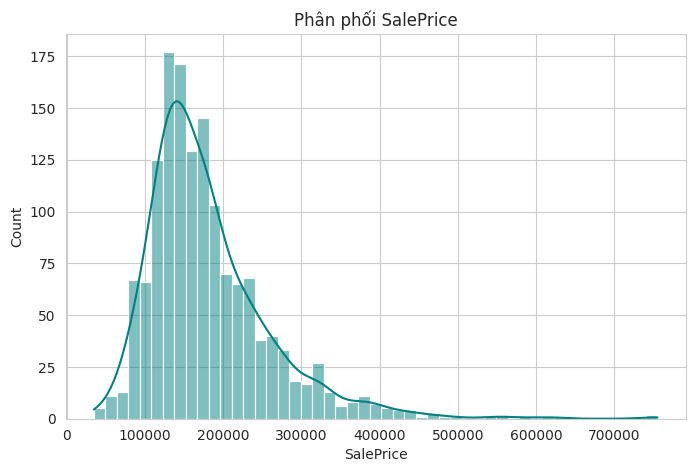

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64
Skewness: 1.8828757597682129


In [3]:
plt.figure(figsize=(8,5))
sns.histplot(train['SalePrice'], kde=True, color='teal')
plt.title('Phân phối SalePrice')
plt.show()

print(train['SalePrice'].describe())
print('Skewness:', train['SalePrice'].skew())

### 2.2. Kiểm tra giá trị thiếu (Missing Values)

In [4]:
print(train.isnull().sum().sort_values(ascending=False).head(20))

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64


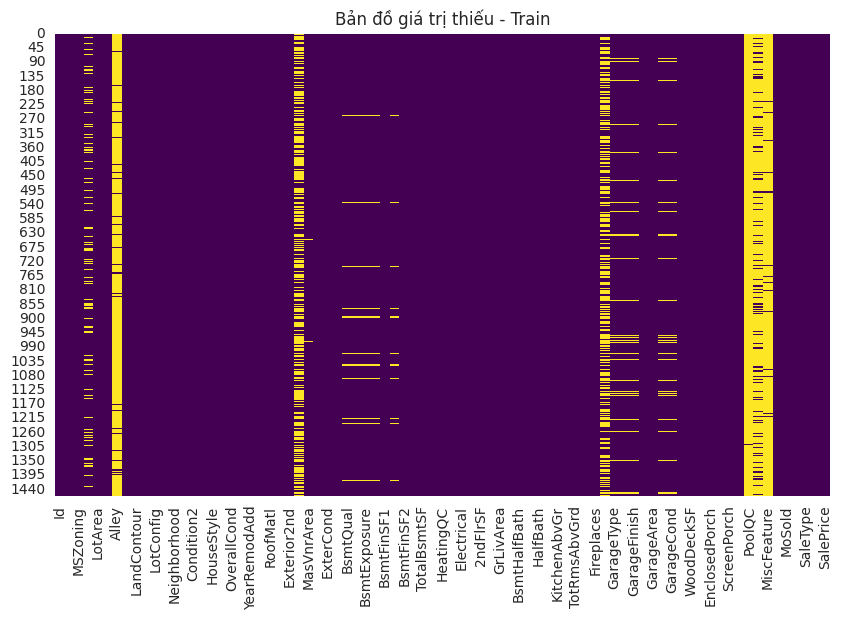

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(train.isnull(), cbar=False, cmap='viridis')
plt.title('Bản đồ giá trị thiếu - Train')
plt.show()

In [6]:
print(test.isnull().sum().sort_values(ascending=False).head(20))

PoolQC          1456
MiscFeature     1408
Alley           1352
Fence           1169
MasVnrType       894
FireplaceQu      730
LotFrontage      227
GarageYrBlt       78
GarageCond        78
GarageFinish      78
GarageQual        78
GarageType        76
BsmtCond          45
BsmtQual          44
BsmtExposure      44
BsmtFinType1      42
BsmtFinType2      42
MasVnrArea        15
MSZoning           4
BsmtHalfBath       2
dtype: int64


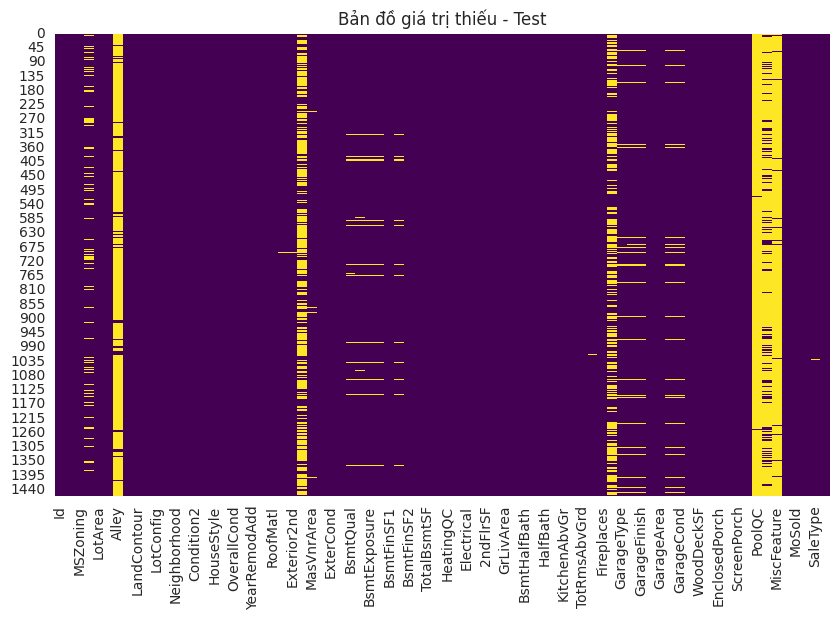

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(test.isnull(), cbar=False, cmap='viridis')
plt.title('Bản đồ giá trị thiếu - Test')
plt.show()

### 2.3. Tương quan giữa các biến số với SalePrice

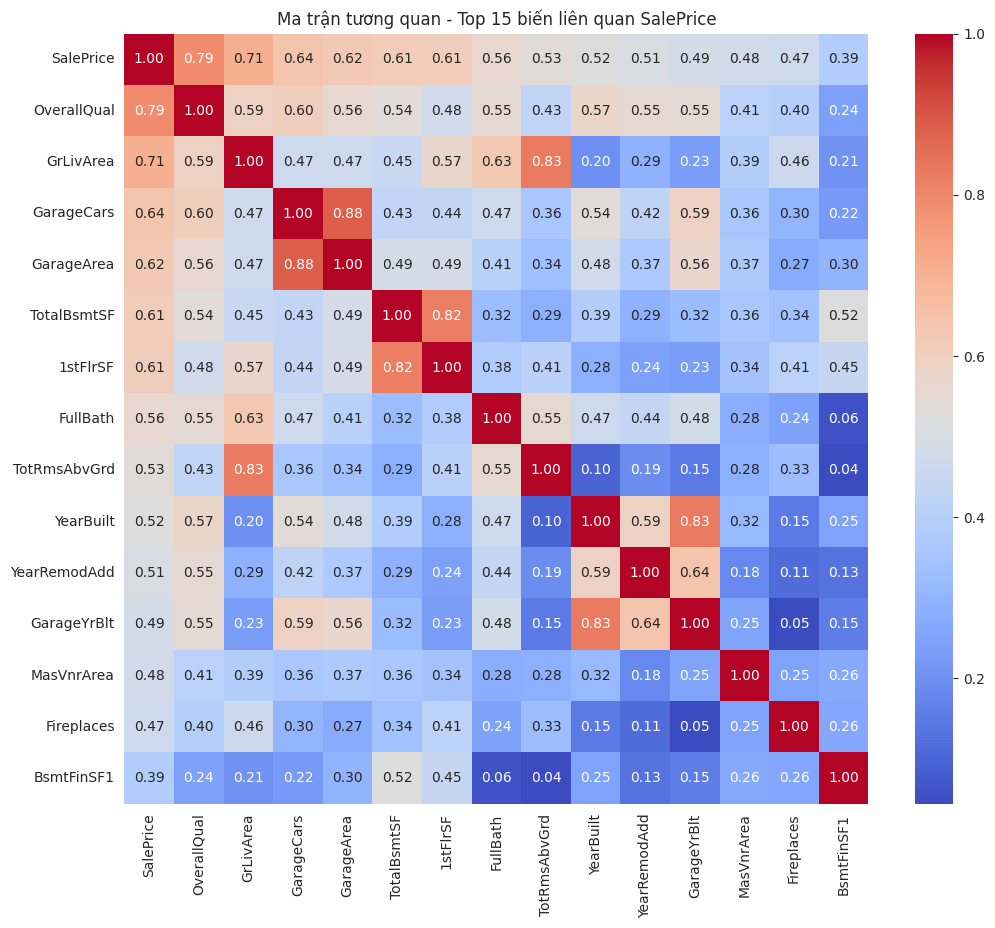

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

In [8]:
num_train = train.select_dtypes(include=[np.number])
corr = num_train.corr()
top_corr_cols = corr['SalePrice'].abs().sort_values(ascending=False).head(15).index
plt.figure(figsize=(12,10))
sns.heatmap(train[top_corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Ma trận tương quan - Top 15 biến liên quan SalePrice')
plt.show()

corr['SalePrice'].abs().sort_values(ascending=False).head(11)

## 3. Xử lý dữ liệu thiếu (Handling NULL Data)

Quan sát: các cột **Alley, PoolQC, Fence, MiscFeature** có hơn 70% giá trị thiếu ở cả tập train và test → loại bỏ các cột này. Cột **Id** không mang thông tin dự đoán → loại bỏ.

- Cột số (numeric): điền giá trị thiếu bằng **giá trị trung bình (mean)** của cột.
- Cột phân loại (categorical): điền giá trị thiếu bằng **giá trị xuất hiện nhiều nhất (mode)** của cột.

In [9]:
cols_to_drop = ['Alley', 'PoolQC', 'Fence', 'MiscFeature', 'Id']

y = train['SalePrice'].copy()
train_ids = train['Id'].copy()
test_ids = test['Id'].copy()

train_feat = train.drop(columns=cols_to_drop + ['SalePrice'], errors='ignore')
test_feat = test.drop(columns=cols_to_drop, errors='ignore')

print('Train sau khi drop cột:', train_feat.shape)
print('Test sau khi drop cột:', test_feat.shape)

Train sau khi drop cột: (1460, 75)
Test sau khi drop cột: (1459, 75)


In [10]:
def fill_missing(df):
    df = df.copy()
    num_cols = df.select_dtypes(include=[np.number]).columns
    cat_cols = df.select_dtypes(exclude=[np.number]).columns
    for c in num_cols:
        if df[c].isnull().any():
            df[c] = df[c].fillna(df[c].mean())
    for c in cat_cols:
        if df[c].isnull().any():
            df[c] = df[c].fillna(df[c].mode()[0])
    return df

train_feat = fill_missing(train_feat)
test_feat = fill_missing(test_feat)

print('Số giá trị null còn lại (train):', train_feat.isnull().sum().sum())
print('Số giá trị null còn lại (test):', test_feat.isnull().sum().sum())

Số giá trị null còn lại (train): 0
Số giá trị null còn lại (test): 0


## 4. Mã hóa biến phân loại (One-Hot Encoding)

Một số giá trị phân loại chỉ xuất hiện ở tập test mà không có ở tập train (hoặc ngược lại). Vì vậy ta **gộp (concat)** hai tập train + test trước khi thực hiện one-hot encoding, sau đó tách lại thành train/test để đảm bảo hai tập có cùng số cột đặc trưng.

In [11]:
n_train = train_feat.shape[0]
combined = pd.concat([train_feat, test_feat], axis=0, ignore_index=True)

cat_cols = combined.select_dtypes(exclude=[np.number]).columns.tolist()
print('Số cột phân loại cần encode:', len(cat_cols))

combined_encoded = pd.get_dummies(combined, columns=cat_cols, drop_first=True)

X_train_full = combined_encoded.iloc[:n_train, :].reset_index(drop=True)
X_test_final = combined_encoded.iloc[n_train:, :].reset_index(drop=True)

print('X_train_full:', X_train_full.shape)
print('X_test_final:', X_test_final.shape)

Số cột phân loại cần encode: 39
X_train_full: (1460, 235)
X_test_final: (1459, 235)


## 5. Tách tập huấn luyện / kiểm định (Train / Validation Split)

In [12]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y, test_size=0.2, random_state=42
)
print('X_tr:', X_tr.shape, ' X_val:', X_val.shape)

X_tr: (1168, 235)  X_val: (292, 235)


## 6. Xây dựng mô hình
### 6.1. Random Forest Regressor

In [13]:
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
rf_pred_val = rf.predict(X_val)

rf_rmse = np.sqrt(mean_squared_error(y_val, rf_pred_val))
rf_mae = mean_absolute_error(y_val, rf_pred_val)
rf_r2 = r2_score(y_val, rf_pred_val)

print(f'Random Forest -> RMSE: {rf_rmse:.2f} | MAE: {rf_mae:.2f} | R2: {rf_r2:.4f}')

Random Forest -> RMSE: 28437.58 | MAE: 17524.40 | R2: 0.8946


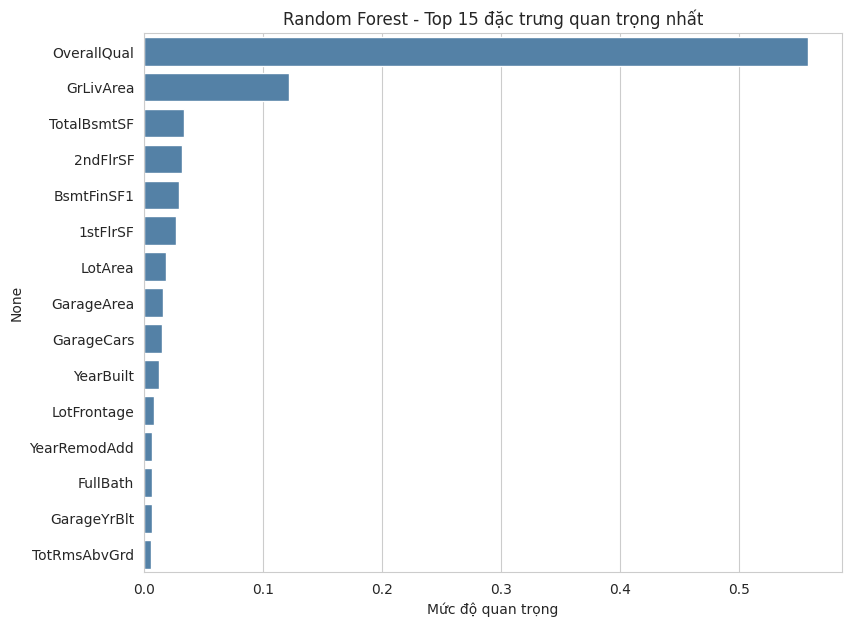

In [14]:
importances = pd.Series(rf.feature_importances_, index=X_tr.columns)\
    .sort_values(ascending=False).head(15)
plt.figure(figsize=(9,7))
sns.barplot(x=importances.values, y=importances.index, color='steelblue')
plt.title('Random Forest - Top 15 đặc trưng quan trọng nhất')
plt.xlabel('Mức độ quan trọng')
plt.show()

### 6.2. Gradient Boosting Regressor

In [15]:
gbr = GradientBoostingRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=3, random_state=42
)
gbr.fit(X_tr, y_tr)
gbr_pred_val = gbr.predict(X_val)

gbr_rmse = np.sqrt(mean_squared_error(y_val, gbr_pred_val))
gbr_mae = mean_absolute_error(y_val, gbr_pred_val)
gbr_r2 = r2_score(y_val, gbr_pred_val)

print(f'Gradient Boosting -> RMSE: {gbr_rmse:.2f} | MAE: {gbr_mae:.2f} | R2: {gbr_r2:.4f}')

Gradient Boosting -> RMSE: 27183.21 | MAE: 16449.88 | R2: 0.9037


## 7. Đánh giá & So sánh mô hình

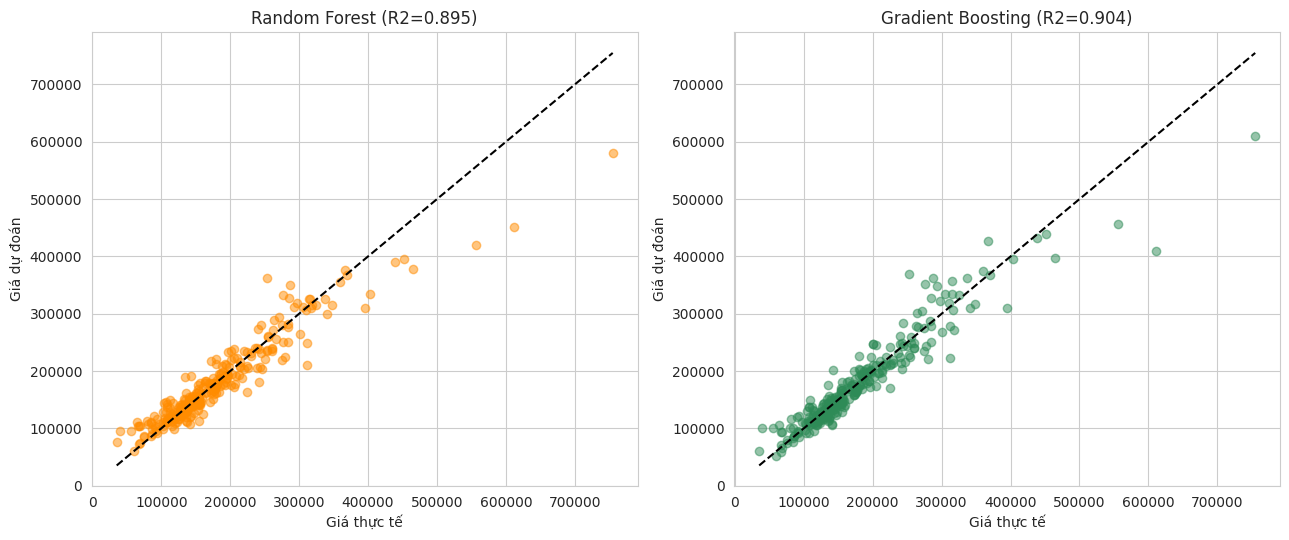

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13,5.5))
axes[0].scatter(y_val, rf_pred_val, alpha=0.5, color='darkorange')
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'k--')
axes[0].set_title(f'Random Forest (R2={rf_r2:.3f})')
axes[0].set_xlabel('Giá thực tế'); axes[0].set_ylabel('Giá dự đoán')

axes[1].scatter(y_val, gbr_pred_val, alpha=0.5, color='seagreen')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'k--')
axes[1].set_title(f'Gradient Boosting (R2={gbr_r2:.3f})')
axes[1].set_xlabel('Giá thực tế'); axes[1].set_ylabel('Giá dự đoán')
plt.tight_layout()
plt.show()

In [17]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting'],
    'RMSE': [rf_rmse, gbr_rmse],
    'MAE': [rf_mae, gbr_mae],
    'R2': [rf_r2, gbr_r2]
})
comparison

,Model,RMSE,MAE,R2
0,Random Forest,28437.57564,17524.398527,0.894568
1,Gradient Boosting,27183.21134,16449.876774,0.903664


## 8. Huấn luyện mô hình tốt nhất trên toàn bộ dữ liệu & Dự đoán tập Test

In [18]:
best_model_name = 'Gradient Boosting' if gbr_rmse < rf_rmse else 'Random Forest'
best_model = gbr if gbr_rmse < rf_rmse else rf
print('Mô hình được chọn:', best_model_name)

best_model.fit(X_train_full, y)
test_pred = best_model.predict(X_test_final)

submission = pd.DataFrame({'Id': test_ids, 'SalePrice': test_pred})
submission.to_csv('submission.csv', index=False)
submission.head()

Mô hình được chọn: Gradient Boosting


,Id,SalePrice
0,1461,119326.972104
1,1462,162952.028328
2,1463,181575.140688
3,1464,187817.182592
4,1465,184282.369743


## 9. Kết luận

- Sau khi xử lý dữ liệu thiếu và mã hóa one-hot, tập dữ liệu có 235 đặc trưng.
- **Gradient Boosting Regressor** cho kết quả tốt hơn **Random Forest Regressor** trên tập validation (RMSE thấp hơn, R² cao hơn), nên được chọn để dự đoán trên tập test.
- Các đặc trưng quan trọng nhất ảnh hưởng đến giá nhà gồm: OverallQual, GrLivArea, TotalBsmtSF, GarageCars, YearBuilt...
- File `submission.csv` chứa kết quả dự đoán cuối cùng để nộp lên Kaggle.